In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")

In [12]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)

In [13]:
def load():
    data = sns.load_dataset("titanic")
    return data

In [14]:
df = load()

In [15]:
def check_df(dataframe, head=5):
    print("#################  Head  #################")
    print(dataframe.head(head))
    print("#################  Tail  ##################")
    print(dataframe.tail(head))
    print("#################  Shape  ##################")
    print(dataframe.shape)
    print("#################  Types  ###################")
    print(dataframe.dtypes)
    print("################# NA  ########################")
    print(dataframe.isnull().sum())
    print("#################  Quantiles  ################")
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)
    

In [16]:
check_df(df)

#################  Head  #################
   survived  pclass     sex   age  sibsp  parch     fare embarked  class    who  adult_male deck  embark_town alive  alone
0         0       3    male  22.0      1      0   7.2500        S  Third    man        True  NaN  Southampton    no  False
1         1       1  female  38.0      1      0  71.2833        C  First  woman       False    C    Cherbourg   yes  False
2         1       3  female  26.0      0      0   7.9250        S  Third  woman       False  NaN  Southampton   yes   True
3         1       1  female  35.0      1      0  53.1000        S  First  woman       False    C  Southampton   yes  False
4         0       3    male  35.0      0      0   8.0500        S  Third    man        True  NaN  Southampton    no   True
#################  Tail  ##################
     survived  pclass     sex   age  sibsp  parch   fare embarked   class    who  adult_male deck  embark_town alive  alone
886         0       2    male  27.0      0      0  

In [17]:
#What is the ratio of missing values in the deck column?
df["deck"].isnull().sum().mean() * 100

np.float64(68800.0)

In [20]:
df["alive"].value_counts()

alive
no     549
yes    342
Name: count, dtype: int64

In [21]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [22]:
df[["class", "pclass"]].head(10)

,class,pclass
0,Third,3
1,First,1
2,Third,3
3,First,1
4,Third,3
5,Third,3
6,First,1
7,Third,3
8,Third,3
9,Second,2


Since survived and alive, as well as class and pclass, carry the same information, we drop one of each; and because the deck variable has more than 60% missing values, we dropped it as well.


In [25]:
df = df.drop(["class", "alive", "deck"],axis=1)

In [91]:
def grab_col_names(dataframe, cat_th = 10, car_th = 20):
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["str","category", "bool"] and
               dataframe[col].nunique() < cat_th]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].dtypes in ["int", "float"] and
    dataframe[col].nunique() < cat_th]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].dtypes == "O" and
                   dataframe[col].nunique() > car_th]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["int", "float"] and
                col not in cat_cols]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")
    return cat_cols, num_cols, cat_but_car
    
    

In [92]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 891
Variables: 15
cat_cols: 12
num_cols: 3
cat_but_car: 0
num_but_cat: 5


In [53]:
#Categorical Varible analysis
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
          "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("#########################################################################")

    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

In [54]:
for col in cat_cols:
    cat_summary(df, col)

        sex      Ratio
sex                   
male    577  64.758698
female  314  35.241302
#########################################################################
          embarked      Ratio
embarked                     
S              644  72.278339
C              168  18.855219
Q               77   8.641975
#########################################################################
       who      Ratio
who                  
man    537  60.269360
woman  271  30.415264
child   83   9.315376
#########################################################################
            adult_male     Ratio
adult_male                      
True               537  60.26936
False              354  39.73064
#########################################################################
             embark_town      Ratio
embark_town                        
Southampton          644  72.278339
Cherbourg            168  18.855219
Queenstown            77   8.641975
########################################

In [55]:
cat_cols

['sex',
 'embarked',
 'who',
 'adult_male',
 'embark_town',
 'alone',
 'survived',
 'pclass',
 'sibsp',
 'parch']

In [56]:
num_cols

['age', 'fare']

In [57]:
cat_but_car

[]

In [70]:
def target_summary_with_cat(dataframe, target, cat):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(cat)[target].mean(),
                       "Count": dataframe[cat].value_counts(),
                       "Ratio": 100 * dataframe[cat].value_counts() / len(dataframe)}), end = "\n\n\n")

for col in cat_cols:
    target_summary_with_cat(df, "survived", col)



        TARGET_MEAN  Count      Ratio
sex                                  
female     0.742038    314  35.241302
male       0.188908    577  64.758698


          TARGET_MEAN  Count      Ratio
embarked                               
C            0.553571    168  18.855219
Q            0.389610     77   8.641975
S            0.336957    644  72.278339


       TARGET_MEAN  Count      Ratio
who                                 
child     0.590361     83   9.315376
man       0.163873    537  60.269360
woman     0.756458    271  30.415264


            TARGET_MEAN  Count     Ratio
adult_male                              
False          0.717514    354  39.73064
True           0.163873    537  60.26936


             TARGET_MEAN  Count      Ratio
embark_town                               
Cherbourg       0.553571    168  18.855219
Queenstown      0.389610     77   8.641975
Southampton     0.336957    644  72.278339


       TARGET_MEAN  Count     Ratio
alone                              
Fa

In [ ]:
#Survival rate combinations

In [71]:
df.groupby(["sex","pclass"])["survived"].mean()

sex     pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64

In [72]:
#Is it more advantageous to be female, or to be in first class?

In [73]:
df.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [74]:
df.groupby("pclass")["survived"].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [ ]:
#Being female is more advantageous

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
5%         4.000000
10%       14.000000
20%       19.000000
30%       22.000000
40%       25.000000
50%       28.000000
60%       31.800000
70%       36.000000
80%       41.000000
90%       50.000000
99%       65.870000
max       80.000000
Name: age, dtype: float64


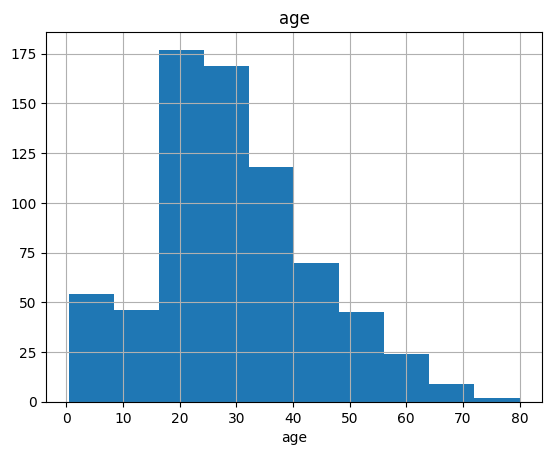

age None
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
5%         7.225000
10%        7.550000
20%        7.854200
30%        8.050000
40%       10.500000
50%       14.454200
60%       21.679200
70%       27.000000
80%       39.687500
90%       77.958300
99%      249.006220
max      512.329200
Name: fare, dtype: float64


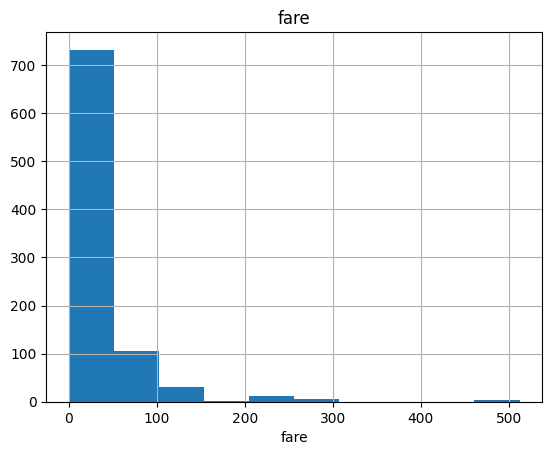

fare None


In [75]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist()
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

for col in num_cols:
    print(col, num_summary(df, col, plot=True))

* Most values are in the 0–50 range

* However, there are a few extreme values between 200–500

* Highly right-skewed

* We will apply log transformation

In [76]:
df["age"].sort_values().tail(10)

832   NaN
837   NaN
839   NaN
846   NaN
849   NaN
859   NaN
863   NaN
868   NaN
878   NaN
888   NaN
Name: age, dtype: float64

In [77]:
df["age"].quantile([0.01, 0.99])

0.01     1.00
0.99    65.87
Name: age, dtype: float64

The extreme values are realistic, not outliers.
If values like 0.99 or 300 had appeared, we would have said there are outliers.

In [78]:
df["fare_log"] = np.log1p(df["fare"])

<Axes: >

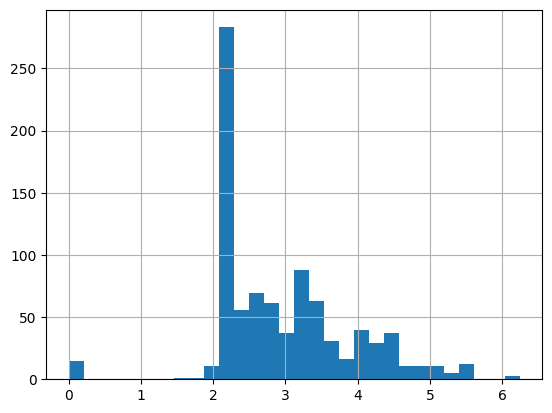

In [79]:
df["fare_log"].hist(bins=30)

* The distribution is more spread out
* The extreme right tail is compressed
* Extreme values are normalized
* The histogram looks more balanced

In [81]:
df["family_size"] = df["sibsp"] + df["parch"]+ 1


In [82]:
df.groupby("family_size")["survived"].mean()

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64

Very large families did not survive at all, but generally, those with families are at an advantage.

In [83]:
df.loc[df["family_size"] == 1, "family_group"] = "alone"
df.loc[(df["family_size"] > 1) & (df["family_size"] <= 4), "family_group"] = "small_family"
df.loc[(df["family_size"] > 4), "family_group"] = "big_family"


In [84]:
df.groupby("family_group")["survived"].mean()

family_group
alone           0.303538
big_family      0.161290
small_family    0.578767
Name: survived, dtype: float64

As you can see, the most advantageous group is small families.

In [86]:
num_cols = df.select_dtypes(include=["int64", "float64"])
num_cols

,survived,pclass,age,sibsp,parch,fare,fare_log,family_size
0,0,3,22.00,1,0,7.2500,2.110213,2
1,1,1,38.00,1,0,71.2833,4.280593,2
2,1,3,26.00,0,0,7.9250,2.188856,1
3,1,1,35.00,1,0,53.1000,3.990834,2
4,0,3,35.00,0,0,8.0500,2.202765,1
5,0,3,NaN,0,0,8.4583,2.246893,1
6,0,1,54.00,0,0,51.8625,3.967694,1
7,0,3,2.00,3,1,21.0750,3.094446,5
8,1,3,27.00,0,2,11.1333,2.495954,3
9,1,2,14.00,1,0,30.0708,3.436268,2


In [89]:
corr_matrix = num_cols.corr()

<Axes: >

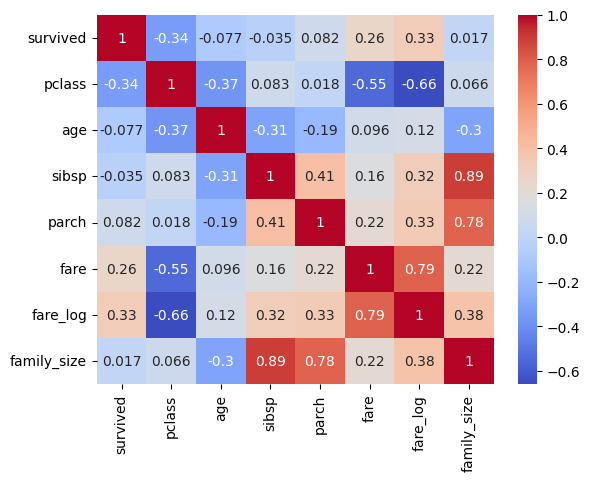

In [90]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

In [93]:
df[["family_size", "sibsp", "parch"]].corr()

,family_size,sibsp,parch
family_size,1.000000,0.890712,0.783111
sibsp,0.890712,1.000000,0.414838
parch,0.783111,0.414838,1.000000


1️⃣ family_size already largely represents sibsp
2️⃣ It also significantly covers parch
3️⃣ However, sibsp and parch are not identical
Perhaps when used together, they can capture different patterns.
If:

You are building a Logistic Regression

→ Due to the risk of multicollinearity

→ It is logical to keep family_size and drop the other two.
If:

You are building a Random Forest

→ Technically, all three can stay

→ But simplifying is generally better.
Since our goal in this study is only to repeat and analyze the graphics, we will keep them.